# Dependencies
#### Run the following file(s) before running this code.
- 03_baseline_similarity_graph.ipynb (or 03b or 03c)
- 07_gds_Louvain_Summary.ipynb

##### Note:
URL of the Neo4j browser:
- https://[IP address]:7473/browser/

ID & Pass: 
- Use the one in .env


In [1]:
import time
from datetime import datetime, timedelta

In [2]:
import os
import sys
import json
import numpy as np
import pandas as pd
from IPython.display import display
import tiktoken

In [3]:
from dotenv import load_dotenv  
load_dotenv()

True

In [4]:
import neo4j

In [5]:
# Ignore unclosed SSL socket warnings - optional in case you get these errors
import warnings

In [6]:
warnings.filterwarnings(action="ignore", message="unclosed", category=ResourceWarning)
warnings.filterwarnings("ignore", category=DeprecationWarning) 

In [7]:
# Show all columns
pd.set_option('display.max_columns', None)

# Show all rows
pd.set_option('display.max_rows', None)

In [8]:
# Timestamp (Start)
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%Y-%m-%d_%H:%M:%S")
print(formatted_time)

start_time = time.time()

2026-01-08_22:03:03


### Neo4j

In [9]:
driver = neo4j.GraphDatabase.driver(
    uri=os.environ.get("NEO4J_URI"), 
    auth=(os.environ.get("NEO4J_USERNAME"), 
          os.environ.get("NEO4J_PASSWORD"))
)

In [10]:
session = driver.session(database="neo4j")

In [11]:
def my_neo4j_run_query_pandas(query, **kwargs):
    "run a query and return the results in a pandas dataframe"
    
    result = session.run(query, **kwargs)
    
    df = pd.DataFrame([r.values() for r in result], columns=result.keys())
    
    return df

### Jupyter visibility config

In [12]:
# Show entire data in a column
pd.set_option('display.max_colwidth', None)

In [13]:
# Center the column title and make the font of the data frame larger

from IPython.display import HTML

HTML("""
<style>
table.dataframe th {
    font-size: 20px !important;
    text-align: center !important;
}
table.dataframe td {
    font-size: 24px !important;
    text-align: left !important;
}
</style>
""")

# Community detection with state as relationship
1) Create a new relation or edge or connection between nodes called SAME_STATE.
2) Connect nodes with complaint ID belonging to same state and similar. Like all complaint belonging to CA, TX..
3) Project in memory graph with relation/edge SAME_STATE and complaint ID
4) Run Louvain community detection algorith to build community based on SAME_STATE and complaint ID relation.
5) Write back results like community ID into NEO4J node as property.
6) Display on neo4j browser as
MATCH (c:Complaint)
RETURN c

This shows nodes on same state in the graph. Business Question: This Louvin community detection algorithm tries to group together complaints nodes based on state relationship. It creates community based of all complaints belonging to same state. The graph projection shows distrubution based on each state. Each state is assigned a community ID. This helps analysing the distrubution of complaints for each state.

In [14]:
query = """
MATCH (node_X:Complaint), (node_Y:Complaint)
WHERE node_X.state = node_Y.state 
  AND elementId(node_X) < elementId(node_Y)
MERGE (node_X)-[:SAME_STATE]->(node_Y);
"""
session.run(query)

In [15]:
query = """
CALL gds.graph.drop('ds_graph', false)
YIELD graphName
RETURN graphName
"""
session.run(query)


query = """
CALL gds.graph.project(
  'ds_graph',
  'Complaint',
  {
    SAME_STATE: {
      type: 'SAME_STATE',
      orientation: 'UNDIRECTED'
    }
  }
);
"""
session.run(query)

In [16]:
query = """
CALL gds.louvain.stream('ds_graph')
YIELD nodeId, communityId
RETURN 
    gds.util.asNode(nodeId).complaint_id AS complaint_id,
    gds.util.asNode(nodeId).state AS state,
    gds.util.asNode(nodeId).consumer_complaint_narrative AS narrative,
    communityId AS state_community_id
ORDER BY state_community_id ASC
"""

community_df = my_neo4j_run_query_pandas(query)



In [17]:
community_df.head(100)

,complaint_id,state,narrative,state_community_id
0,13939523,AL,"I bought a bed from on //. The promotion I was presented that was offered through Synchrony Home credit card was supposed to be for 48 months no interest which is what I agreed to. When I received my first statement the next month, the promotional rate stated it was for a 18 month no interest financing promotion, I immediately contacted and was told this was an error and they would fix it. After I received my next statement still with the wrong promotion on it, I contacted the on // and they sent me a receipt through email stating they fixed the issue along with the items receipt. I contacted Synchrony multiple times by phone and live chat online. They stated today when I contacted them that they would give me only the online chat dated // with and . // with , and // with and would not give me the lists of times I've called. They have yet to rectify this issue after I think I have done my part contacting both the store that sold me the products and their financing person as well as Synchrony who it was financed through. After I file this complaint, I plan on speaking to a lawyer about breach of contract.",4
1,13883114,AL,"World Acceptance Corp , SC is reporting late payments on my credit reports for a loan that never existed between myself and their company. I have asked the company to provide a contract of said {$390.00} loan with my signature, and have not received any documentation. If this documentation can not be produced, I am demanding immediate removal of this incorrect information from my credit report.",4
2,13847134,AL,"Company failed to provide me with any documentation by delivering to incorrect address when current address was provided for verification of debt. The company stated in a previous response that they arent the owner of this debt and they shouldnt be reporting any of this information on my report because it isnt their debt. This is illegal and they have violated my rights. I submitted a written dispute to said creditor regarding an account that is inaccurate and/or unverifiable. Under 15 USC 1681i, I ha ve the legal right to a full reinvestigation. The company failed to properly investigate and continues to report inaccurate information. Additionally, they are in violation of : - 1681s-2 for reporting false or unverified data, - 1681e ( b ) for failing to ensure maximum possible accuracy, - 1681c for reporting obsolete/outdated information. I demand that this account be immediately removed as it violates multiple federal laws. I request that the CFPB step in and force compliance with the FCRA. Failure to resolve this issue constitutes willful noncompliance under federal law.",4
3,13842806,AL,"Account number I am filing a dispute regarding a debt reported on my credit. I am unaware of this debt and have not received proper documentation validating it. Specifically, I have not been provided with verification that includes a copy of the original agreement bearing my signature or any detailed account history establishing my obligation to this debt. Under the Fair Debt Collection Practices Act ( FDCPA ), I am entitled to complete verification of the debt. Until such verification is provided, including documentation with my signature and full validation of the alleged debt, I request that all collection efforts and credit reporting be ceased. Please provide this documentation via certified mail, including a return receipt displaying my signature as proof of delivery. If the required documentation is not provided and collection or reporting efforts continue, I will have no choice but to pursue all available legal remedies to protect my rights.",4
4,13936040,AL,"All, I currently have an auto loan with Truist Bank for USD . On //year>, I requested that Truist provide us with a payoff letter so we can refinance with another bank at a lower interest rate. When I reached out to Truist to request a payoff letter, I was told that Truist only provides pay

In [18]:
community_df.columns

Index(['complaint_id', 'state', 'narrative', 'state_community_id'], dtype='object')

In [19]:
query = """
CALL gds.louvain.write('ds_graph', {
  writeProperty: 'state_community_id'
});
"""
session.run(query)

In [20]:
# 1. Constraint
query = """
CREATE CONSTRAINT state_unique IF NOT EXISTS
FOR (sc:State)
REQUIRE sc.state IS UNIQUE
"""
session.run(query)

# 2. Create category nodes for each state
query = """
MATCH (c:Complaint)
WHERE c.state IS NOT NULL
WITH DISTINCT c.state AS state_val
MERGE (sc:State {state: state_val})
"""
session.run(query)

# 3. Link Complaints to their StateCategory
query = """
MATCH (c:Complaint)
WHERE c.state IS NOT NULL
MATCH (sc:State {state: c.state})
MERGE (c)-[:IN_STATE]->(sc);
"""
session.run(query)



<Axes: title={'center': 'State Community Sizes'}, xlabel='state'>

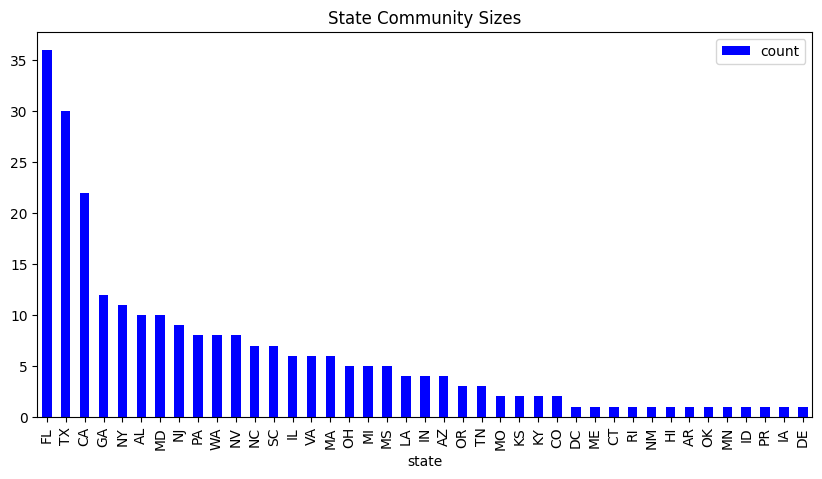

In [21]:
state_community_sizes = community_df["state"].value_counts().reset_index()

state_community_sizes.plot.bar(x="state", y="count", figsize=(10,5), color="blue", title="State Community Sizes")

In [22]:
query = """
MATCH (sc:State)<-[:IN_STATE]-(comp:Complaint)
    -[:IN_CATEGORY]->(cat:Category)

// Note:
// - pairCount: Number of complaints
WITH sc, cat,
     count(comp) AS pairCount

MERGE (cat)-[r:IN_STATE]->(sc)
SET r.num = pairCount;

"""

session.run(query)

### Remove Complaint nodes before moving to the next step

In [23]:
query = """

MATCH (n:Complaint)
DETACH DELETE n;

"""

session.run(query)

### Degree centrality analysis

In [24]:
# Drop the existing in-memory graph
query = """
CALL gds.graph.drop('ds_graph', false)
YIELD graphName
RETURN graphName
"""
session.run(query)


# Create an in-memory graph named 'ds_graph'
# Nodes: Category, State
# Relationship: IN_STATE, weighted by r.pairCount
query = """
CALL gds.graph.project(
    'ds_graph', 
    ['Category', 'State'], 
    {
        IN_STATE: {
            type: 'IN_STATE', 
            orientation: 'NATURAL',
            properties: 'num'
        }
    }
)
"""

session.run(query)

In [25]:
# Note: 'REVERSE': Count the incoming relationships to State nodes
query = """
CALL gds.degree.stream(
    'ds_graph',
    {orientation: 'REVERSE'}
)
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
WHERE n:State
RETURN n.state AS State, score AS Degree
ORDER BY Degree DESC, State;
"""

my_neo4j_run_query_pandas(query).head(5)

,State,Degree
0,FL,10.0
1,TX,9.0
2,CA,8.0
3,NY,8.0
4,WA,8.0


In [26]:
# # Drop the existing in-memory graph
# query = """
# CALL gds.graph.drop('ds_graph', false)
# YIELD graphName
# RETURN graphName
# """
# session.run(query)


# # Create an in-memory graph named 'ds_graph'
# # Nodes: Category, State
# # Relationship: IN_STATE, weighted by r.pairCount
# query = """
# CALL gds.graph.project(
#     'ds_graph', 
#     ['Category', 'State'], 
#     {
#         IN_STATE: {
#             type: 'IN_STATE', 
#             orientation: 'NATURAL',
#             properties: 'num'
#         }
#     }
# )
# """

# session.run(query)

In [27]:
query = """
CALL gds.degree.stream(
    'ds_graph'
)
YIELD nodeId, score
WITH gds.util.asNode(nodeId) AS n, score
WHERE n:Category
RETURN n.summary AS Category, score AS Degree
ORDER BY Degree DESC, Category;
"""

my_neo4j_run_query_pandas(query).head(5)

,Category,Degree
0,Consumer complaints about unverified debts and inaccurate credit reporting.,33.0
1,Consumer complaints regarding unauthorized account actions and identity theft.,27.0
2,Consumer complaints about inadequate fraud resolution and unresponsive customer service.,23.0
3,Consumer complaints about erroneous credit reporting and unresolved disputes.,19.0
4,Consumer complaints about excessive holds on funds and account access issues.,17.0


In [28]:
# Timestamp (End)
current_datetime = datetime.now()
formatted_time = current_datetime.strftime("%Y-%m-%d_%H:%M:%S")
print(formatted_time)

end_time = time.time()
elapsed_seconds = end_time - start_time

# Convert elapsed seconds to minutes and seconds
minutes = int(elapsed_seconds // 60)
seconds = elapsed_seconds % 60

print(f"Program elapsed time: {minutes} minutes and {seconds:.2f} seconds")

2026-01-08_22:03:07
Program elapsed time: 0 minutes and 3.64 seconds
